In [1]:
!pip install solara
!pip install mesa

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.8/108.8 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.9/268.9 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.5/71.5 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.1/275.1 kB 5.9 MB/s eta 0:00:00


In [2]:
import mesa
import random
#from mesa.visualization import SolaraViz, make_space_component
#from ipywidgets import interact, IntSlider, FloatSlider
import solara
#from IPython.display import display, HTML
import pandas as pd

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


In [3]:
# ========== AGENTE ==========
class Persona(mesa.Agent):
    def __init__(self, model, tipo: int, se_ha_movido: bool) -> None:
        super().__init__(model)
        self.tipo = tipo
        self.se_ha_movido = se_ha_movido

    def incomodidad(self, pos, tipo):
        contador = 0
        vecindad = self.model.grid.get_neighbors(pos, moore=True, include_center=False)
        if tipo == 1:
            for vecino in vecindad:
                if vecino.tipo == -1: contador += 1
        elif tipo == -1:
            for vecino in vecindad:
                if vecino.tipo == 1: contador += 1
        elif tipo == 0:
            for vecino in vecindad:
                contador += abs(vecino.tipo)
        return contador

    def move(self):
        self.se_ha_movido = False
        possible_steps = []
        radio = 0
        max_iteraciones = self.model.grid.width // 2 + 1
        incomodidad_base = self.incomodidad(self.pos, self.tipo)

        if incomodidad_base > self.model.tolerance:
            while not possible_steps and radio < max_iteraciones:
                radio += 1
                vecindario = self.model.grid.get_neighborhood(
                    self.pos, moore=True, include_center=False, radius=radio
                )
                empty_steps = [step for step in vecindario if self.model.grid.is_cell_empty(step)]
                possible_steps = [step for step in empty_steps if self.incomodidad(step, self.tipo) < incomodidad_base]

        if possible_steps:
            new_position = random.choice(possible_steps)
            self.model.grid.move_agent(self, new_position)
            self.se_ha_movido = True

# ========== MODELO ==========
class Modelo_Desplazamiento(mesa.Model):
    def __init__(self, N1, N2, N3, width, height, tol, seed=None):
        super().__init__(seed=seed)
        self.num_agents = N1 + N2 + N3
        self.unsatisfied_count = 0
        self.unsatisfied_by_type = {-1: 0, 0: 0, 1: 0}     # << nuevo
        #self.agent_counts = {-1: 0, 0: 0, 1: 0}
        self.grid = mesa.space.SingleGrid(width, height, True)
        self.running = True
        self.tolerance = tol
        self.steps_to_equilibrium = 0
        self.in_equilibrium = False
        self.contact_measure = {}
        self.datacollector = mesa.DataCollector(
            model_reporters={
                "Steps_to_Equilibrium": "steps_to_equilibrium",
                "Contact_Measure": "contact_measure",
                "In_Equilibrium": "in_equilibrium",
                # insatisfechos
                "Unsatisfied_Total": lambda m: m.unsatisfied_count,
                "Unsatisfied_-1":    lambda m: m.unsatisfied_by_type[-1],
                "Unsatisfied_0":     lambda m: m.unsatisfied_by_type[0],
                "Unsatisfied_1":     lambda m: m.unsatisfied_by_type[1],
            }
        )

        for i in range(N1): Persona(model=self, tipo=1, se_ha_movido=False)
        for i in range(N2): Persona(model=self, tipo=0, se_ha_movido=False)
        for i in range(N3): Persona(model=self, tipo=-1, se_ha_movido=False)

        placed_agents = set()
        for i in range(self.num_agents):
            agent = self.agents[i]
            x, y = random.randrange(self.grid.width), random.randrange(self.grid.height)
            while (x, y) in placed_agents:
                x, y = random.randrange(self.grid.width), random.randrange(self.grid.height)
            placed_agents.add((x, y))
            self.grid.place_agent(agent, (x, y))

        self.calculate_contact_measure()

    def calculate_contact_measure(self):
        """Calcula la medida de contacto desagregada por tipo de agente"""
        contact_counts = {
            -1: {-1: 0, 0: 0, 1: 0},
             0: {-1: 0, 0: 0, 1: 0},
             1: {-1: 0, 0: 0, 1: 0},
        }
        Total_contacts = 0

        for agent in self.agents:
            neighbors = self.grid.get_neighbors(agent.pos, moore=True, include_center=False)
            for neighbor in neighbors:
                contact_counts[agent.tipo][neighbor.tipo] += 1
                Total_contacts += 1

        Total_contacts = Total_contacts / 2

        for i in [-1,0,1]: contact_counts[i][i] = contact_counts[i][i] / 2

        # Guardamos proporciones
        self.contact_measure = {}
        for agent_type in [-1, 0, 1]:
            self.contact_measure[agent_type] = {}
            for neighbor_type in [-1, 0, 1]:
                if Total_contacts > 0:
                    self.contact_measure[agent_type][neighbor_type] = (
                        contact_counts[agent_type][neighbor_type] / Total_contacts
                    )
                else:
                    self.contact_measure[agent_type][neighbor_type] = 0

    def calculate_unsatisfied(self):
        """Cuenta agentes insatisfechos por tipo."""
        counts = {-1: 0, 0: 0, 1: 0}
        for agent in self.agents:
            if agent.incomodidad(agent.pos, agent.tipo) > self.tolerance:
                counts[agent.tipo] += 1
        self.unsatisfied_by_type = counts
        self.unsatisfied_count = sum(counts.values())

    def check_equilibrium(self) -> bool:
        """Verifica si el modelo ha alcanzado el equilibrio"""
        for agent in self.agents:
            if agent.se_ha_movido:
                return False
        return True

    def step(self):
        if not self.in_equilibrium:
            self.agents.shuffle_do("move")
            self.calculate_contact_measure()
            self.calculate_unsatisfied()

            if self.check_equilibrium():
                self.in_equilibrium = True
                self.running = False
            else:
                self.steps_to_equilibrium += 1

            self.datacollector.collect(self)



In [ ]:
### agregamos T y discriminamos I_0, I_1, I_-1. La tolerancia se modifica por usuario.

import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt

# ========= FUNCIONES AUXILIARES =========

def aplanar_contact_measure(contact_measure):
    fila = {}
    for i in [-1, 0, 1]:
        for j in [-1, 0, 1]:
            fila[f"C_{i}_{j}"] = contact_measure[i][j]
    return fila


def contar_tipos(modelo):
    conteos = {-1: 0, 0: 0, 1: 0}
    for agent in modelo.agents:
        conteos[agent.tipo] += 1
    return conteos


def calcular_T(modelo):
    """
    Calcula el total de contactos entre agentes.

    Cada contacto se cuenta dos veces al recorrer todos los agentes,
    por eso al final se divide por 2.
    """
    total = 0

    for agent in modelo.agents:
        vecinos = modelo.grid.get_neighbors(
            agent.pos,
            moore=True,
            include_center=False
        )
        total += len(vecinos)

    return total / 2


def calcular_I(modelo):
    """
    Calcula los componentes de la función de insatisfacción.

    Definimos:

        I_0  = C_{0,1} + C_{0,-1}
        I_1  = C_{1,-1}
        I_-1 = C_{1,-1}

    Por tanto:

        I_norm = I_0 + I_1 + I_-1

    y la insatisfacción total escalada es:

        I = 2T * I_norm

    Es decir:

        I = 2T(2C_{1,-1} + C_{0,1} + C_{0,-1})
    """

    modelo.calculate_contact_measure()

    T = calcular_T(modelo)
    C = modelo.contact_measure

    # Componentes normalizados
    I_0 = C[0][1] + C[0][-1]
    I_1 = C[1][-1]
    I_m1 = C[1][-1]

    # Insatisfacción total normalizada
    I_norm = I_0 + I_1 + I_m1

    # Insatisfacción total escalada por el número total de contactos
    I = 2 * T * I_norm

    return T, I, I_norm, I_0, I_1, I_m1


def extraer_fila(modelo, paso, corrida, total_agentes):
    modelo.calculate_contact_measure()
    modelo.calculate_unsatisfied()

    T, I, I_norm, I_0, I_1, I_m1 = calcular_I(modelo)
    conteos = contar_tipos(modelo)

    fila = {
        "corrida": corrida,
        "step": paso,
        "tol": modelo.tolerance,
        "N_total_objetivo": total_agentes,
        "N_total_modelo": modelo.num_agents,

        # Cantidad de agentes por tipo
        "N1": conteos[1],
        "N2": conteos[0],
        "N3": conteos[-1],

        # Estado dinámico del modelo
        "in_equilibrium": modelo.in_equilibrium,
        "running": modelo.running,
        "steps_to_equilibrium_attr": modelo.steps_to_equilibrium,

        # Agentes insatisfechos
        "Unsatisfied_Total": modelo.unsatisfied_count,
        "Unsatisfied_-1": modelo.unsatisfied_by_type[-1],
        "Unsatisfied_0": modelo.unsatisfied_by_type[0],
        "Unsatisfied_1": modelo.unsatisfied_by_type[1],

        # Agentes movidos en el último paso
        "Agents_moved_last_step": sum(agent.se_ha_movido for agent in modelo.agents),

        # Total de contactos
        "T_contacts": T,

        # Insatisfacción total escalada
        "I_disatisfaccion": I,

        # Insatisfacción total normalizada
        "I_norm": I_norm,

        # Componentes discriminados de la insatisfacción
        "I_0": I_0,
        "I_1": I_1,
        "I_-1": I_m1,
    }

    # Agrega las entradas C_{i,j}
    fila.update(aplanar_contact_measure(modelo.contact_measure))

    return fila


def ejecutar_barrido_total_fijo_excel(
    total_agentes=1500,
    width=40,
    height=40,
    tol=3,
    N2_inicial=0,
    N2_final=1500,
    salto_N2=100,
    archivo_excel="contactos_total_1500_barrido_N2.xlsx",
    guardar_paso_inicial=True,
    incluir_paso_equilibrio=True,
    max_steps=10000,
    semilla_base=1234
):
    resultados = []
    resumen = []

    capacidad = width * height
    corrida = 0

    if capacidad < total_agentes:
        raise ValueError(
            f"La grilla tiene solo {capacidad} celdas y necesitas al menos {total_agentes}."
        )

    for N2 in range(N2_inicial, N2_final + 1, salto_N2):

        restante = total_agentes - N2

        if restante < 0:
            print(f"Se omite N2={N2} porque excede el total de agentes.")
            continue

        if restante % 2 != 0:
            print(f"Se omite N2={N2} porque ({total_agentes} - N2)/2 no es entero.")
            continue

        N1 = restante // 2
        N3 = restante // 2

        print(
            f"Ejecutando corrida {corrida}: "
            f"N1={N1}, N2={N2}, N3={N3}, tol={tol}"
        )

        modelo = Modelo_Desplazamiento(
            N1=N1,
            N2=N2,
            N3=N3,
            width=width,
            height=height,
            tol=tol,
            seed=semilla_base + corrida
        )

        paso = 0

        if guardar_paso_inicial:
            resultados.append(
                extraer_fila(modelo, paso, corrida, total_agentes)
            )

        while modelo.running and paso < max_steps:
            modelo.step()
            paso += 1

            if modelo.in_equilibrium and not incluir_paso_equilibrio:
                break

            resultados.append(
                extraer_fila(modelo, paso, corrida, total_agentes)
            )

        resumen.append({
            "corrida": corrida,
            "N1": N1,
            "N2": N2,
            "N3": N3,
            "tol": tol,
            "width": width,
            "height": height,
            "pasos_guardados": paso + 1 if guardar_paso_inicial else paso,
            "steps_to_equilibrium_attr": modelo.steps_to_equilibrium,
            "in_equilibrium": modelo.in_equilibrium,
            "running_final": modelo.running,
        })

        corrida += 1

    df_pasos = pd.DataFrame(resultados)
    df_resumen = pd.DataFrame(resumen)

    with pd.ExcelWriter(archivo_excel, engine="openpyxl") as writer:
        df_pasos.to_excel(writer, sheet_name="Todos_los_pasos", index=False)
        df_resumen.to_excel(writer, sheet_name="Resumen_por_N2", index=False)

    print(f"\nArchivo guardado como: {archivo_excel}")
    print(f"Total de filas guardadas: {len(df_pasos)}")

    return df_pasos, df_resumen, archivo_excel


# ========= PARÁMETROS =========

TOTAL_AGENTES = 1500
WIDTH = 40
HEIGHT = 40

# Cambia aquí la tolerancia fija:
TOLERANCIA_FIJA = 0


# ========= EJECUCIÓN =========

df_pasos, df_resumen, archivo_generado = ejecutar_barrido_total_fijo_excel(
    total_agentes=TOTAL_AGENTES,
    width=WIDTH,
    height=HEIGHT,
    tol=TOLERANCIA_FIJA,
    N2_inicial=0,
    N2_final=1500,
    salto_N2=100,
    archivo_excel=f"contactos_total_1500_barrido_N2_tol{TOLERANCIA_FIJA}.xlsx",
    guardar_paso_inicial=True,
    incluir_paso_equilibrio=True,
    max_steps=10000,
    semilla_base=1234
)

display(df_resumen)
display(df_pasos.head(20))

from google.colab import files

files.download(archivo_generado)

Ejecutando corrida 0: N1=750, N2=0, N3=750, tol=0


/usr/local/lib/python3.12/dist-packages/mesa/mesa_logging.py:112: FutureWarning: The use of the `seed` keyword argument is deprecated, use `rng` instead. No functional changes.
  res = func(*args, **kwargs)


Ejecutando corrida 1: N1=700, N2=100, N3=700, tol=0
Ejecutando corrida 2: N1=650, N2=200, N3=650, tol=0
Ejecutando corrida 3: N1=600, N2=300, N3=600, tol=0
Ejecutando corrida 4: N1=550, N2=400, N3=550, tol=0
Ejecutando corrida 5: N1=500, N2=500, N3=500, tol=0
Ejecutando corrida 6: N1=450, N2=600, N3=450, tol=0
Ejecutando corrida 7: N1=400, N2=700, N3=400, tol=0
Ejecutando corrida 8: N1=350, N2=800, N3=350, tol=0
Ejecutando corrida 9: N1=300, N2=900, N3=300, tol=0
Ejecutando corrida 10: N1=250, N2=1000, N3=250, tol=0
Ejecutando corrida 11: N1=200, N2=1100, N3=200, tol=0
Ejecutando corrida 12: N1=150, N2=1200, N3=150, tol=0
Ejecutando corrida 13: N1=100, N2=1300, N3=100, tol=0
Ejecutando corrida 14: N1=50, N2=1400, N3=50, tol=0
Ejecutando corrida 15: N1=0, N2=1500, N3=0, tol=0

Archivo guardado como: contactos_total_1500_barrido_N2_tol0.xlsx
Total de filas guardadas: 116


,corrida,N1,N2,N3,tol,width,height,pasos_guardados,steps_to_equilibrium_attr,in_equilibrium,running_final
0,0,750,0,750,0,40,40,17,15,True,False
1,1,700,100,700,0,40,40,10,8,True,False
2,2,650,200,650,0,40,40,12,10,True,False
3,3,600,300,600,0,40,40,12,10,True,False
4,4,550,400,550,0,40,40,7,5,True,False
5,5,500,500,500,0,40,40,8,6,True,False
6,6,450,600,450,0,40,40,7,5,True,False
7,7,400,700,400,0,40,40,6,4,True,False
8,8,350,800,350,0,40,40,5,3,True,False
9,9,300,900,300,0,40,40,7,5,True,False


,corrida,step,tol,N_total_objetivo,N_total_modelo,N1,N2,N3,in_equilibrium,running,...,I_-1,C_-1_-1,C_-1_0,C_-1_1,C_0_-1,C_0_0,C_0_1,C_1_-1,C_1_0,C_1_1
0,0,0,0,1500,1500,750,0,750,False,True,...,0.509427,0.245642,0.000000,0.509427,0.000000,0.000000,0.000000,0.509427,0.000000,0.244931
1,0,1,0,1500,1500,750,0,750,False,True,...,0.265062,0.365419,0.000000,0.265062,0.000000,0.000000,0.000000,0.265062,0.000000,0.369519
2,0,2,0,1500,1500,750,0,750,False,True,...,0.186432,0.405805,0.000000,0.186432,0.000000,0.000000,0.000000,0.186432,0.000000,0.407764
3,0,3,0,1500,1500,750,0,750,False,True,...,0.150009,0.424194,0.000000,0.150009,0.000000,0.000000,0.000000,0.150009,0.000000,0.425797
4,0,4,0,1500,1500,750,0,750,False,True,...,0.129124,0.435884,0.000000,0.129124,0.000000,0.000000,0.000000,0.129124,0.000000,0.434992
5,0,5,0,1500,1500,750,0,750,False,True,...,0.119137,0.441056,0.000000,0.119137,0.000000,0.000000,0.000000,0.119137,0.000000,0.439807
6,0,6,0,1500,1500,750,0,750,False,True,...,0.113430,0.443731,0.000000,0.113430,0.000000,0.000000,0.000000,0.113430,0.000000,0.442839
7,0,7,0,1500,1500,750,0,750,False,True,...,0.108831,0.446566,0.000000,0.108831,0.000000,0.000000,0.000000,0.108831,0.000000,0.444603
8,0,8,0,1500,1500,750,0,750,False,True,...,0.104691,0.448725,0.000000,0.104691,0.000000,0.000000,0.000000,0.104691,0.000000,0.446585
9,0,9,0,1500,1500,750,0,750,False,True,...,0.100000,0.451337,0.000000,0.100000,0.000000,0.000000,0.000000,0.100000,0.000000,0.448663


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os

try:
    from google.colab import files
    files.download(archivo_generado)
except Exception:
    print("No estás en Google Colab.")
    print("El archivo quedó guardado en:")
    print(os.path.abspath(archivo_generado))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

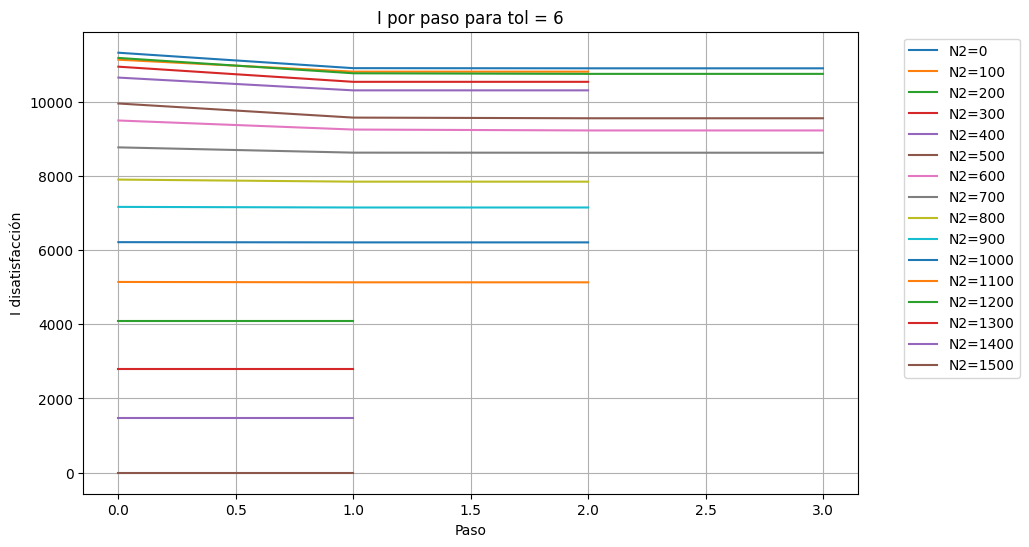

In [ ]:
###gráficas, I contra paso para cada N_2
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for n2, grupo in df_pasos.groupby("N2"):
    grupo = grupo.sort_values("step")
    plt.plot(grupo["step"], grupo["I_disatisfaccion"], label=f"N2={n2}")

plt.xlabel("Paso")
plt.ylabel("I disatisfacción")
plt.title(f"I por paso para tol = {TOLERANCIA_FIJA}")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.show()

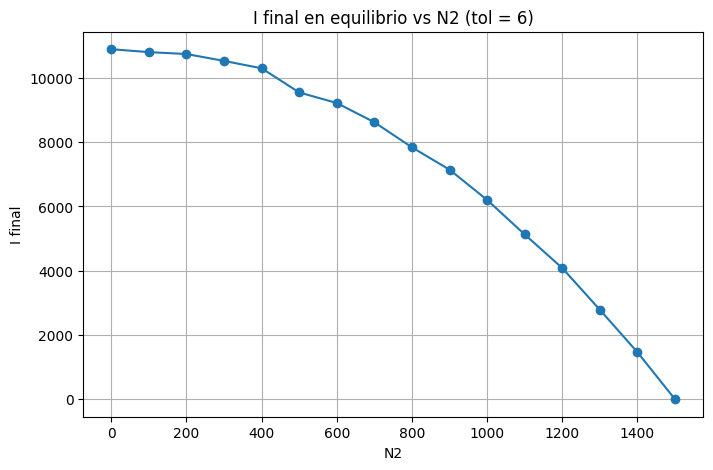

In [ ]:
###gráficas, valor final de I al equilibrio contra N_2

df_final = (
    df_pasos.sort_values("step")
    .groupby("N2", as_index=False)
    .last()
)

plt.figure(figsize=(8, 5))
plt.plot(df_final["N2"], df_final["I_disatisfaccion"], marker="o")
plt.xlabel("N2")
plt.ylabel("I final")
plt.title(f"I final en equilibrio vs N2 (tol = {TOLERANCIA_FIJA})")
plt.grid(True)
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Ejemplo de Graficado con Datos desde un Archivo Excel
Aquí te muestro cómo puedes cargar datos desde un archivo Excel y usarlos para generar una gráfica similar a la anterior. Asegúrate de reemplazar 'tu_archivo.xlsx' con la ruta correcta de tu archivo y de que tu archivo Excel contenga las columnas necesarias.

Datos cargados exitosamente desde 'contactos_total_1500_barrido_N2_tol6.xlsx' (hoja: 'Todos_los_pasos')


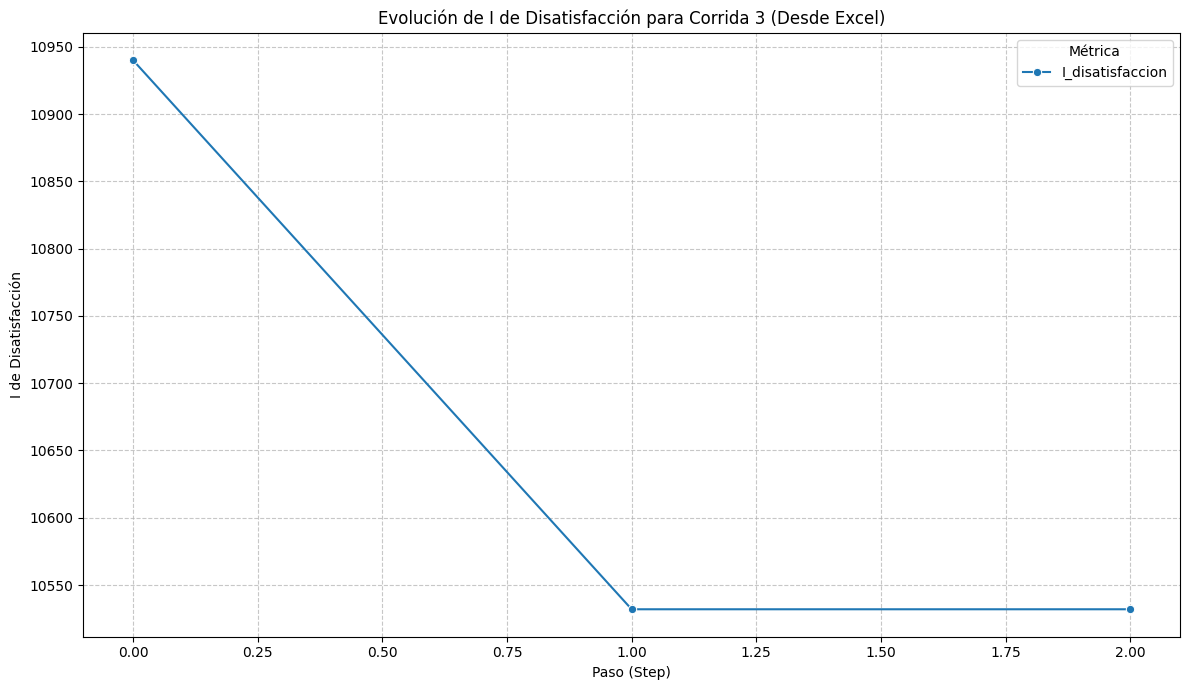

In [ ]:
####Este Me permite a partir de un archivo de  excel graficar I
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- CONFIGURACIÓN --- #
# Reemplaza 'tu_archivo.xlsx' con el nombre de tu archivo Excel
excel_file_path = 'contactos_total_1500_barrido_N2_tol6.xlsx' # Por ejemplo, usamos el archivo generado anteriormente
sheet_name = 'Todos_los_pasos' # Nombre de la hoja en tu archivo Excel
corrida_a_graficar = 3 # La corrida específica que quieres graficar de tu Excel

# --- Cargar datos desde Excel --- #
try:
    df_desde_excel = pd.read_excel(excel_file_path, sheet_name=sheet_name)
    print(f"Datos cargados exitosamente desde '{excel_file_path}' (hoja: '{sheet_name}')")
except FileNotFoundError:
    print(f"Error: El archivo '{excel_file_path}' no fue encontrado.")
    print("Asegúrate de que el archivo existe y la ruta es correcta.")
    df_desde_excel = pd.DataFrame() # Crear un DataFrame vacío para evitar errores posteriores
except Exception as e:
    print(f"Ocurrió un error al cargar el archivo Excel: {e}")
    df_desde_excel = pd.DataFrame() # Crear un DataFrame vacío

# --- Graficar si los datos se cargaron correctamente --- #
if not df_desde_excel.empty:
    # Filtrar df_desde_excel para la corrida específica
    df_corrida_excel = df_desde_excel[df_desde_excel['corrida'] == corrida_a_graficar].copy()

    if not df_corrida_excel.empty:
        # Seleccionar y renombrar las columnas de interés para la gráfica
        # Asegúrate de que 'I_disatisfaccion' sea el nombre correcto de tu columna en el Excel
        plot_data_excel_melted = df_corrida_excel.melt(
            id_vars=['step'],
            value_vars=['I_disatisfaccion'],
            var_name='Métrica',
            value_name='Valor'
        )

        # Crear la gráfica
        plt.figure(figsize=(12, 7))
        sns.lineplot(
            data=plot_data_excel_melted,
            x='step',
            y='Valor',
            hue='Métrica',
            marker='o'
        )

        plt.title(f'Evolución de I de Disatisfacción para Corrida {corrida_a_graficar} (Desde Excel)')
        plt.xlabel('Paso (Step)')
        plt.ylabel('I de Disatisfacción')
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.legend(title='Métrica')
        plt.tight_layout()
        plt.show()
    else:
        print(f"No se encontraron datos para la corrida {corrida_a_graficar} en el archivo Excel.")
else:
    print("No se pudo graficar porque el DataFrame está vacío o no se cargó correctamente.")

In [ ]:
!pip install openpyxl

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
uploaded = files.upload()

excel_file_path = 'contactos_total_1500_barrido_N2_tol6.xlsx'
sheet_name = 'Todos_los_pasos'
TOLERANCIA_FIJA = 6

df_pasos = pd.read_excel(excel_file_path, sheet_name=sheet_name)
print(df_pasos.head())

TypeError: 'NoneType' object is not subscriptable

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# CONFIGURACIÓN GENERAL DE ESTILO PARA ARTÍCULO
# ============================================================
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "legend.fontsize": 10,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "mathtext.fontset": "cm",   # estilo matemático tipo Computer Modern
    "text.usetex": False        # poner True solo si tienes LaTeX instalado
})

sns.set_style("whitegrid")


# ============================================================
# FUNCIÓN PARA CARGAR EL EXCEL
# ============================================================
def cargar_datos_excel(excel_file_path, sheet_name="Todos_los_pasos"):
    try:
        df = pd.read_excel(excel_file_path, sheet_name=sheet_name)
        print(f"Datos cargados exitosamente desde '{excel_file_path}' (hoja: '{sheet_name}')")
        return df
    except FileNotFoundError:
        print(f"Error: no se encontró el archivo '{excel_file_path}'")
        return pd.DataFrame()
    except Exception as e:
        print(f"Ocurrió un error al cargar el archivo: {e}")
        return pd.DataFrame()


# ============================================================
# 1) GRÁFICA I vs STEP PARA CADA N2
#    Puedes fijar una corrida o promediar todas las corridas
# ============================================================
def graficar_I_por_step_segun_N2(df, tolerancia, corrida=None, guardar=False, nombre_salida=None):
    if df.empty:
        print("El DataFrame está vacío.")
        return

    # Si se especifica corrida, filtramos
    if corrida is not None:
        df_plot = df[df["corrida"] == corrida].copy()
        subtitulo = f"corrida = {corrida}"
    else:
        df_plot = df.copy()
        subtitulo = "promedio sobre corridas"

    if df_plot.empty:
        print("No hay datos para el filtro seleccionado.")
        return

    plt.figure(figsize=(10, 6))

    if corrida is not None:
        # Una curva por cada N2 para una corrida fija
        for n2, grupo in df_plot.groupby("N2"):
            grupo = grupo.sort_values("step")
            plt.plot(
                grupo["step"],
                grupo["I_disatisfaccion"],
                marker=None,
                linewidth=2,
                label=rf"$N_2={n2}$"
            )
    else:
        # Promediar I_disatisfaccion sobre corridas para cada (N2, step)
        resumen = (
            df_plot.groupby(["N2", "step"], as_index=False)["I_disatisfaccion"]
            .mean()
        )

        for n2, grupo in resumen.groupby("N2"):
            grupo = grupo.sort_values("step")
            plt.plot(
                grupo["step"],
                grupo["I_disatisfaccion"],
                linewidth=2,
                label=rf"$N_2={n2}$"
            )

    plt.xlabel(r"Paso")
    plt.ylabel(r"$I$")
    plt.title(rf"Evolución de $I$ según $N_0$ para tolerancia = {tolerancia} ({subtitulo})")
    plt.legend(
        title=r"Valores de $N_0$",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        frameon=True
    )
    plt.tight_layout()

    if guardar:
        if nombre_salida is None:
            nombre_salida = f"I_vs_step_tol_{tolerancia}.pdf"
        plt.savefig(nombre_salida, dpi=300, bbox_inches="tight")
        print(f"Figura guardada en: {nombre_salida}")

    plt.show()


# ============================================================
# 2) RESUMEN: VALOR FINAL DE I vs N2
#    Útil para un artículo porque condensa la información
# ============================================================
def graficar_I_final_vs_N2(df, tolerancia, guardar=False, nombre_salida=None):
    if df.empty:
        print("El DataFrame está vacío.")
        return

    # Tomamos, para cada corrida y N2, el último step disponible
    idx_final = df.groupby(["corrida", "N2"])["step"].idxmax()
    df_final = df.loc[idx_final].copy()

    # Promedio del valor final de I para cada N2
    resumen = (
        df_final.groupby("N2", as_index=False)["I_disatisfaccion"]
        .agg(["mean", "std", "count"])
        .reset_index()
    )

    resumen["sem"] = resumen["std"] / (resumen["count"] ** 0.5)

    plt.figure(figsize=(9, 6))
    plt.errorbar(
        resumen["N2"],
        resumen["mean"],
        yerr=resumen["sem"],
        fmt='o-',
        capsize=4,
        linewidth=2
    )

    plt.xlabel(r"$N_0$")
    plt.ylabel(r"Valor final promedio de $I$")
    plt.title(rf"Valor final de $I$ en función de $N_0$ (tol = {tolerancia})")
    plt.tight_layout()

    if guardar:
        if nombre_salida is None:
            nombre_salida = f"I_final_vs_N2_tol_{tolerancia}.pdf"
        plt.savefig(nombre_salida, dpi=300, bbox_inches="tight")
        print(f"Figura guardada en: {nombre_salida}")

    plt.show()


# ============================================================
# 3) RESUMEN: PROMEDIO TEMPORAL DE I vs N2
# ============================================================
def graficar_I_promedio_vs_N2(df, tolerancia, guardar=False, nombre_salida=None):
    if df.empty:
        print("El DataFrame está vacío.")
        return

    # Promedio temporal por corrida y N2
    df_prom_corrida = (
        df.groupby(["corrida", "N2"], as_index=False)["I_disatisfaccion"]
        .mean()
    )

    # Luego promedio entre corridas
    resumen = (
        df_prom_corrida.groupby("N2", as_index=False)["I_disatisfaccion"]
        .agg(["mean", "std", "count"])
        .reset_index()
    )

    resumen["sem"] = resumen["std"] / (resumen["count"] ** 0.5)

    plt.figure(figsize=(9, 6))
    plt.errorbar(
        resumen["N2"],
        resumen["mean"],
        yerr=resumen["sem"],
        fmt='s-',
        capsize=4,
        linewidth=2
    )

    plt.xlabel(r"$N_0$")
    plt.ylabel(r"Promedio temporal de $I$")
    plt.title(rf"Promedio temporal de $I$ en función de $N_0$ (tol = {tolerancia})")
    plt.tight_layout()

    if guardar:
        if nombre_salida is None:
            nombre_salida = f"I_promedio_vs_N2_tol_{tolerancia}.pdf"
        plt.savefig(nombre_salida, dpi=300, bbox_inches="tight")
        print(f"Figura guardada en: {nombre_salida}")

    plt.show()


# ============================================================
# EJEMPLO DE USO
# ============================================================
excel_file_path = "contactos_total_1500_barrido_N2_tol0 (1).xlsx"
sheet_name = "Todos_los_pasos"
TOLERANCIA_FIJA = 0

df_pasos = cargar_datos_excel(excel_file_path, sheet_name=sheet_name)

if not df_pasos.empty:
    # 1) Una corrida específica
    graficar_I_por_step_segun_N2(
        df_pasos,
        tolerancia=TOLERANCIA_FIJA,
        corrida=3,
        guardar=True,
        nombre_salida="I_vs_step_por_N2_corrida3_tol0.pdf"
    )

    # 2) Promedio sobre corridas
    graficar_I_por_step_segun_N2(
        df_pasos,
        tolerancia=TOLERANCIA_FIJA,
        corrida=None,
        guardar=True,
        nombre_salida="I_vs_step_por_N2_promedio_tol0.pdf"
    )

    # 3) Resumen por valor final
    graficar_I_final_vs_N2(
        df_pasos,
        tolerancia=TOLERANCIA_FIJA,
        guardar=True,
        nombre_salida="I_final_vs_N2_tol0.pdf"
    )

    # 4) Resumen por promedio temporal
    graficar_I_promedio_vs_N2(
        df_pasos,
        tolerancia=TOLERANCIA_FIJA,
        guardar=True,
        nombre_salida="I_promedio_vs_N2_tol0.pdf"
    )

Error: no se encontró el archivo 'contactos_total_1500_barrido_N2_tol0 (1).xlsx'


In [ ]:
!pip install openpyxl

import re
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

# ============================================================
# ESTILO GENERAL PARA FIGURAS DE ARTÍCULO
# ============================================================
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "legend.fontsize": 10,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "mathtext.fontset": "cm",
    "text.usetex": False   # En Colab conviene dejarlo en False
})
sns.set_style("whitegrid")


# ============================================================
# CONFIGURACIÓN
# ============================================================
sheet_name = "Todos_los_pasos"
guardar_figuras = True
carpeta_salida = "figuras"
corrida_especifica = None       # None = promedio sobre corridas; o un entero, por ejemplo 3


# ============================================================
# SUBIR ARCHIVO EXCEL
# ============================================================
uploaded = files.upload()

if len(uploaded) == 0:
    raise ValueError("No se subió ningún archivo.")

excel_file_path = next(iter(uploaded.keys()))
print(f"Archivo seleccionado: {excel_file_path}")


# ============================================================
# FUNCIONES AUXILIARES
# ============================================================
def inferir_tolerancia_desde_nombre(nombre_archivo):
    """
    Intenta extraer algo tipo tol0, tol0.25, tol_0_3, etc.
    """
    nombre = os.path.basename(nombre_archivo).lower()

    patrones = [
        r'tol(?:erancia)?[_\-]?([0-9]+(?:[._][0-9]+)?)',
        r'tol(?:erancia)?\s*=\s*([0-9]+(?:[._][0-9]+)?)'
    ]

    for patron in patrones:
        m = re.search(patron, nombre)
        if m:
            valor = m.group(1).replace("_", ".")
            try:
                return float(valor)
            except:
                return valor
    return "desconocida"


def normalizar_nombre_columna(nombre):
    """
    Normaliza nombres para detectar columnas aunque cambien paréntesis,
    llaves, comas, guiones, espacios, etc.
    """
    nombre = str(nombre).lower().strip()
    nombre = nombre.replace("menos", "m")
    nombre = nombre.replace("neg", "m")
    nombre = nombre.replace("-1", "m1")
    nombre = re.sub(r'[^a-z0-9]+', '', nombre)
    return nombre


def encontrar_columna(df, candidatos):
    """
    Busca una columna exacta o aproximada dentro del DataFrame.
    """
    columnas = list(df.columns)

    # 1) Búsqueda exacta
    for c in candidatos:
        if c in columnas:
            return c

    # 2) Búsqueda normalizada
    columnas_norm = {normalizar_nombre_columna(c): c for c in columnas}
    for c in candidatos:
        c_norm = normalizar_nombre_columna(c)
        if c_norm in columnas_norm:
            return columnas_norm[c_norm]

    return None


def cargar_datos_excel(excel_file_path, sheet_name="Todos_los_pasos"):
    try:
        df = pd.read_excel(excel_file_path, sheet_name=sheet_name)
        print(f"Datos cargados exitosamente desde '{excel_file_path}' (hoja: '{sheet_name}')")
        return df
    except FileNotFoundError:
        print(f"Error: no se encontró el archivo '{excel_file_path}'")
        return pd.DataFrame()
    except Exception as e:
        print(f"Ocurrió un error al cargar el archivo: {e}")
        return pd.DataFrame()


def revisar_columnas_base(df):
    columnas_obligatorias = ["corrida", "N2", "step"]
    faltantes = [c for c in columnas_obligatorias if c not in df.columns]
    if faltantes:
        raise ValueError(f"Faltan columnas obligatorias en el Excel: {faltantes}")


def preparar_carpeta_salida(carpeta):
    if guardar_figuras:
        os.makedirs(carpeta, exist_ok=True)


def guardar_figura(nombre_base):
    if guardar_figuras:
        ruta_pdf = os.path.join(carpeta_salida, f"{nombre_base}.pdf")
        ruta_png = os.path.join(carpeta_salida, f"{nombre_base}.png")

        plt.savefig(ruta_pdf, bbox_inches="tight")
        plt.savefig(ruta_png, dpi=300, bbox_inches="tight")

        print(f"Figura guardada en:")
        print(f" - {ruta_pdf}")
        print(f" - {ruta_png}")


# ============================================================
# RESÚMENES ESTADÍSTICOS
# ============================================================
def resumen_evolucion(df, metrica, corrida=None):
    """
    Devuelve datos para graficar evolución por paso según N2.
    - corrida=None  -> promedio sobre corridas
    - corrida=int   -> una corrida específica
    """
    if corrida is not None:
        df_plot = df[df["corrida"] == corrida].copy()
        return df_plot.groupby(["N2", "step"], as_index=False)[metrica].mean(), f"corrida = {corrida}"
    else:
        df_plot = df.copy()
        return df_plot.groupby(["N2", "step"], as_index=False)[metrica].mean(), "promedio sobre corridas"


def resumen_final_vs_N2(df, metrica):
    """
    Para cada (corrida, N2), toma el valor del último step;
    luego promedia entre corridas para cada N2.
    """
    idx_final = df.groupby(["corrida", "N2"])["step"].idxmax()
    df_final = df.loc[idx_final].copy()

    resumen = (
        df_final.groupby("N2")[metrica]
        .agg(media="mean", std="std", n="count")
        .reset_index()
    )
    resumen["std"] = resumen["std"].fillna(0)
    resumen["sem"] = resumen["std"] / np.sqrt(resumen["n"])
    return resumen


def resumen_promedio_vs_N2(df, metrica):
    """
    Promedio temporal por (corrida, N2),
    luego promedio entre corridas para cada N2.
    """
    df_prom_corrida = (
        df.groupby(["corrida", "N2"], as_index=False)[metrica]
        .mean()
    )

    resumen = (
        df_prom_corrida.groupby("N2")[metrica]
        .agg(media="mean", std="std", n="count")
        .reset_index()
    )
    resumen["std"] = resumen["std"].fillna(0)
    resumen["sem"] = resumen["std"] / np.sqrt(resumen["n"])
    return resumen


# ============================================================
# FUNCIONES DE GRÁFICA
# ============================================================
def graficar_evolucion_por_N2(df, metrica, etiqueta_y, titulo_metrica, tolerancia, corrida=None):
    datos, subtitulo = resumen_evolucion(df, metrica, corrida=corrida)

    if datos.empty:
        print(f"No hay datos para graficar {metrica}.")
        return

    plt.figure(figsize=(10, 6))

    for n2, grupo in datos.groupby("N2"):
        grupo = grupo.sort_values("step")
        plt.plot(
            grupo["step"],
            grupo[metrica],
            linewidth=2.2,
            label=rf"$N_0={n2}$"
        )

    plt.xlabel(r"Paso")
    plt.ylabel(etiqueta_y)
    plt.title(rf"Evolución de {titulo_metrica} según $N_0$ ($\tau = {tolerancia}$, {subtitulo})")
    plt.legend(
        title=r"Valores de $N_0$",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        frameon=True
    )
    plt.tight_layout()

    sufijo = f"corrida_{corrida}" if corrida is not None else "promedio_corridas"
    guardar_figura(f"evolucion_{metrica}_vs_step_tol_{tolerancia}_{sufijo}")

    plt.show()


def graficar_resumen_vs_N2(resumen, etiqueta_y, titulo, nombre_archivo):
    if resumen.empty:
        print(f"No hay datos para graficar {nombre_archivo}.")
        return

    plt.figure(figsize=(9, 6))
    plt.errorbar(
        resumen["N2"],
        resumen["media"],
        yerr=resumen["sem"],
        fmt='o-',
        capsize=4,
        linewidth=2
    )
    plt.xlabel(r"$N_0$")
    plt.ylabel(etiqueta_y)
    plt.title(titulo)
    plt.tight_layout()

    guardar_figura(nombre_archivo)

    plt.show()


# ============================================================
# CARGA DE DATOS
# ============================================================
df_pasos = cargar_datos_excel(excel_file_path, sheet_name=sheet_name)

if df_pasos.empty:
    raise ValueError("El DataFrame quedó vacío. Revisa el archivo o la hoja seleccionada.")

revisar_columnas_base(df_pasos)
preparar_carpeta_salida(carpeta_salida)

TOLERANCIA_FIJA = inferir_tolerancia_desde_nombre(excel_file_path)

print("\nColumnas encontradas en el archivo:")
print(list(df_pasos.columns))


# ============================================================
# DETECCIÓN DE COLUMNAS DE MÉTRICAS
# ============================================================
col_I = encontrar_columna(df_pasos, [
    "I_disatisfaccion", "I_disatisfacción", "I", "Idisatisfaccion"
])

col_C_1_m1 = encontrar_columna(df_pasos, [
    "C_1_m1", "C_1_-1", "C_{1,-1}", "C(1,-1)", "C1m1", "C_1menos1"
])

col_C_0_m1 = encontrar_columna(df_pasos, [
    "C_0_m1", "C_0_-1", "C_{0,-1}", "C(0,-1)", "C0m1", "C_0menos1"
])

col_C_0_1 = encontrar_columna(df_pasos, [
    "C_0_1", "C_{0,1}", "C(0,1)", "C01", "C_0,1"
])

metricas = []

if col_I is not None:
    metricas.append((col_I, r"$I$", r"$I$"))
else:
    print("No se encontró la columna de I_disatisfaccion.")

if col_C_1_m1 is not None:
    metricas.append((col_C_1_m1, r"$C_{1,-1}$", r"$C_{1,-1}$"))
else:
    print("No se encontró la columna de C_{1,-1}.")

if col_C_0_m1 is not None:
    metricas.append((col_C_0_m1, r"$C_{0,-1}$", r"$C_{0,-1}$"))
else:
    print("No se encontró la columna de C_{0,-1}.")

if col_C_0_1 is not None:
    metricas.append((col_C_0_1, r"$C_{0,1}$", r"$C_{0,1}$"))
else:
    print("No se encontró la columna de C_{0,1}.")

if len(metricas) == 0:
    raise ValueError("No se detectó ninguna métrica para graficar.")


print("\nMétricas detectadas:")
for col, ylab, tit in metricas:
    print(f" - {col}  -->  {tit}")


# ============================================================
# (1) y (2): EVOLUCIÓN SEGÚN N2 SOBRE CORRIDAS
# ============================================================
for col, etiqueta_y, titulo_metrica in metricas:
    graficar_evolucion_por_N2(
        df_pasos,
        metrica=col,
        etiqueta_y=etiqueta_y,
        titulo_metrica=titulo_metrica,
        tolerancia=TOLERANCIA_FIJA,
        corrida=corrida_especifica
    )


# ============================================================
# (3) y (4): VALOR FINAL Y PROMEDIO DE I EN FUNCIÓN DE N2
# ============================================================
if col_I is not None:
    resumen_I_final = resumen_final_vs_N2(df_pasos, col_I)
    graficar_resumen_vs_N2(
        resumen_I_final,
        etiqueta_y=r"Valor final promedio de $I$",
        titulo=rf"Valor final de $I$ en función de $N_0$ ($\tau = {TOLERANCIA_FIJA}$)",
        nombre_archivo=f"I_final_vs_N2_tol_{TOLERANCIA_FIJA}"
    )

    resumen_I_prom = resumen_promedio_vs_N2(df_pasos, col_I)
    graficar_resumen_vs_N2(
        resumen_I_prom,
        etiqueta_y=r"Promedio temporal de $I$",
        titulo=rf"Promedio temporal de $I$ en función de $N_0$ ($\tau = {TOLERANCIA_FIJA}$)",
        nombre_archivo=f"I_promedio_vs_N2_tol_{TOLERANCIA_FIJA}"
    )


# ============================================================
# (5) y (6): VALOR FINAL Y PROMEDIO DE C_{i,j} EN FUNCIÓN DE N2
# ============================================================
metricas_contacto = [
    (col_C_1_m1, r"$C_{1,-1}$"),
    (col_C_0_m1, r"$C_{0,-1}$"),
    (col_C_0_1,  r"$C_{0,1}$")
]

for col, latex_label in metricas_contacto:
    if col is not None:
        resumen_final = resumen_final_vs_N2(df_pasos, col)
        graficar_resumen_vs_N2(
            resumen_final,
            etiqueta_y=rf"Valor final promedio de {latex_label}",
            titulo=rf"Valor final de {latex_label} en función de $N_0$ ($\tau = {TOLERANCIA_FIJA}$)",
            nombre_archivo=f"{col}_final_vs_N2_tol_{TOLERANCIA_FIJA}"
        )

        resumen_prom = resumen_promedio_vs_N2(df_pasos, col)
        graficar_resumen_vs_N2(
            resumen_prom,
            etiqueta_y=rf"Promedio temporal de {latex_label}",
            titulo=rf"Promedio temporal de {latex_label} en función de $N_0$ ($\tau = {TOLERANCIA_FIJA}$)",
            nombre_archivo=f"{col}_promedio_vs_N2_tol_{TOLERANCIA_FIJA}"
        )


# ============================================================
# DESCARGAR TODAS LAS FIGURAS EN UN ZIP
# ============================================================
import shutil
from google.colab import files

nombre_zip = f"graficos_tol_{TOLERANCIA_FIJA}"
shutil.make_archive(nombre_zip, 'zip', carpeta_salida)

files.download(f"{nombre_zip}.zip")

KeyboardInterrupt: 

In [ ]:
####Graficamos por valores fijos de agentes neutrales.
### agregamos T y discriminamos I_0, I_1, I_-1. La tolerancia se modifica por usuario.

import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt

# ========= FUNCIONES AUXILIARES =========

def aplanar_contact_measure(contact_measure):
    fila = {}
    for i in [-1, 0, 1]:
        for j in [-1, 0, 1]:
            fila[f"C_{i}_{j}"] = contact_measure[i][j]
    return fila


def contar_tipos(modelo):
    conteos = {-1: 0, 0: 0, 1: 0}
    for agent in modelo.agents:
        conteos[agent.tipo] += 1
    return conteos


def calcular_T(modelo):
    """
    Calcula el total de contactos entre agentes.

    Cada contacto se cuenta dos veces al recorrer todos los agentes,
    por eso al final se divide por 2.
    """
    total = 0

    for agent in modelo.agents:
        vecinos = modelo.grid.get_neighbors(
            agent.pos,
            moore=True,
            include_center=False
        )
        total += len(vecinos)

    return total / 2


def calcular_I(modelo):
    """
    Calcula los componentes de la función de insatisfacción.

    Definimos:

        I_0  = C_{0,1} + C_{0,-1}
        I_1  = C_{1,-1}
        I_-1 = C_{1,-1}

    Por tanto:

        I_norm = I_0 + I_1 + I_-1

    y la insatisfacción total escalada es:

        I = 2T * I_norm

    Es decir:

        I = 2T(2C_{1,-1} + C_{0,1} + C_{0,-1})
    """

    modelo.calculate_contact_measure()

    T = calcular_T(modelo)
    C = modelo.contact_measure

    # Componentes normalizados
    I_0 = C[0][1] + C[0][-1]
    I_1 = C[1][-1]
    I_m1 = C[1][-1]

    # Insatisfacción total normalizada
    I_norm = I_0 + I_1 + I_m1

    # Insatisfacción total escalada por el número total de contactos
    I = 2 * T * I_norm

    return T, I, I_norm, I_0, I_1, I_m1


def extraer_fila(modelo, paso, corrida, total_agentes):
    modelo.calculate_contact_measure()
    modelo.calculate_unsatisfied()

    T, I, I_norm, I_0, I_1, I_m1 = calcular_I(modelo)
    conteos = contar_tipos(modelo)

    fila = {
        "corrida": corrida,
        "step": paso,
        "tol": modelo.tolerance,
        "N_total_objetivo": total_agentes,
        "N_total_modelo": modelo.num_agents,

        # Cantidad de agentes por tipo
        "N1": conteos[1],
        "N2": conteos[0],
        "N3": conteos[-1],

        # Estado dinámico del modelo
        "in_equilibrium": modelo.in_equilibrium,
        "running": modelo.running,
        "steps_to_equilibrium_attr": modelo.steps_to_equilibrium,

        # Agentes insatisfechos
        "Unsatisfied_Total": modelo.unsatisfied_count,
        "Unsatisfied_-1": modelo.unsatisfied_by_type[-1],
        "Unsatisfied_0": modelo.unsatisfied_by_type[0],
        "Unsatisfied_1": modelo.unsatisfied_by_type[1],

        # Agentes movidos en el último paso
        "Agents_moved_last_step": sum(agent.se_ha_movido for agent in modelo.agents),

        # Total de contactos
        "T_contacts": T,

        # Insatisfacción total escalada
        "I_disatisfaccion": I,

        # Insatisfacción total normalizada
        "I_norm": I_norm,

        # Componentes discriminados de la insatisfacción
        "I_0": I_0,
        "I_1": I_1,
        "I_-1": I_m1,
    }

    # Agrega las entradas C_{i,j}
    fila.update(aplanar_contact_measure(modelo.contact_measure))

    return fila


def ejecutar_barrido_total_fijo_excel(
    total_agentes=1500,
    width=40,
    height=40,
    tol=3,
    N2_inicial=0,
    N2_final=1500,
    salto_N2=100,
    archivo_excel="contactos_total_1500_barrido_N2.xlsx",
    guardar_paso_inicial=True,
    incluir_paso_equilibrio=True,
    max_steps=10000,
    semilla_base=1234
):
    resultados = []
    resumen = []

    capacidad = width * height
    corrida = 0

    if capacidad < total_agentes:
        raise ValueError(
            f"La grilla tiene solo {capacidad} celdas y necesitas al menos {total_agentes}."
        )

    for N2 in range(N2_inicial, N2_final + 1, salto_N2):

        restante = total_agentes - N2

        if restante < 0:
            print(f"Se omite N2={N2} porque excede el total de agentes.")
            continue

        if restante % 2 != 0:
            print(f"Se omite N2={N2} porque ({total_agentes} - N2)/2 no es entero.")
            continue

        N1 = restante // 2
        N3 = restante // 2

        print(
            f"Ejecutando corrida {corrida}: "
            f"N1={N1}, N2={N2}, N3={N3}, tol={tol}"
        )

        modelo = Modelo_Desplazamiento(
            N1=N1,
            N2=N2,
            N3=N3,
            width=width,
            height=height,
            tol=tol,
            seed=semilla_base + corrida
        )

        paso = 0

        if guardar_paso_inicial:
            resultados.append(
                extraer_fila(modelo, paso, corrida, total_agentes)
            )

        while modelo.running and paso < max_steps:
            modelo.step()
            paso += 1

            if modelo.in_equilibrium and not incluir_paso_equilibrio:
                break

            resultados.append(
                extraer_fila(modelo, paso, corrida, total_agentes)
            )

        resumen.append({
            "corrida": corrida,
            "N1": N1,
            "N2": N2,
            "N3": N3,
            "tol": tol,
            "width": width,
            "height": height,
            "pasos_guardados": paso + 1 if guardar_paso_inicial else paso,
            "steps_to_equilibrium_attr": modelo.steps_to_equilibrium,
            "in_equilibrium": modelo.in_equilibrium,
            "running_final": modelo.running,
        })

        corrida += 1

    df_pasos = pd.DataFrame(resultados)
    df_resumen = pd.DataFrame(resumen)

    with pd.ExcelWriter(archivo_excel, engine="openpyxl") as writer:
        df_pasos.to_excel(writer, sheet_name="Todos_los_pasos", index=False)
        df_resumen.to_excel(writer, sheet_name="Resumen_por_N2", index=False)

    print(f"\nArchivo guardado como: {archivo_excel}")
    print(f"Total de filas guardadas: {len(df_pasos)}")

    return df_pasos, df_resumen, archivo_excel


# ========= PARÁMETROS =========

TOTAL_AGENTES = 1500
WIDTH = 40
HEIGHT = 40

# Cambia aquí la tolerancia fija:
TOLERANCIA_FIJA = 0


# ========= EJECUCIÓN =========

df_pasos, df_resumen, archivo_generado = ejecutar_barrido_total_fijo_excel(
    total_agentes=TOTAL_AGENTES,
    width=WIDTH,
    height=HEIGHT,
    tol=TOLERANCIA_FIJA,
    N2_inicial=300,
    N2_final=300,
    salto_N2=100,
    archivo_excel=f"contactos_total_1500_barrido_N2_tol{TOLERANCIA_FIJA}.xlsx",
    guardar_paso_inicial=True,
    incluir_paso_equilibrio=True,
    max_steps=10000,
    semilla_base=1234
)

display(df_resumen)
display(df_pasos.head(20))

from google.colab import files

files.download(archivo_generado)

In [ ]:
### Graficamos I, I_0, I_1 para valores fijos de N_0 y tau

!pip install openpyxl

import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

# ============================================================
# ESTILO GENERAL PARA FIGURAS DE ARTÍCULO
# ============================================================

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "legend.fontsize": 10,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "mathtext.fontset": "cm",
    "text.usetex": False
})

sns.set_style("whitegrid")


# ============================================================
# PARÁMETROS DEL ARCHIVO
# ============================================================

sheet_name = "Todos_los_pasos"

# Como el archivo ya tiene N0 y tau fijos, los declaramos aquí
TOTAL_AGENTES = 1500
N0_FIJO = 700
TAU_FIJA = 6

# Automáticamente:
N1_FIJO = (TOTAL_AGENTES - N0_FIJO) / 2
Nm1_FIJO = (TOTAL_AGENTES - N0_FIJO) / 2

# Si quieres graficar una corrida particular, escribe por ejemplo 0, 1, 2...
# Si quieres promediar sobre corridas, deja None.
corrida_especifica = None

guardar_figuras = True
carpeta_salida = "figuras_I_componentes"

os.makedirs(carpeta_salida, exist_ok=True)


# ============================================================
# SUBIR ARCHIVO EXCEL
# ============================================================

uploaded = files.upload()

if len(uploaded) == 0:
    raise ValueError("No se subió ningún archivo.")

excel_file_path = next(iter(uploaded.keys()))
print(f"Archivo seleccionado: {excel_file_path}")


# ============================================================
# CARGAR DATOS
# ============================================================

df = pd.read_excel(excel_file_path, sheet_name=sheet_name)

print("Columnas encontradas:")
print(list(df.columns))


# ============================================================
# VERIFICACIÓN DE COLUMNAS
# ============================================================

columnas_necesarias = ["step", "I_disatisfaccion", "I_0", "I_1"]

for col in columnas_necesarias:
    if col not in df.columns:
        raise ValueError(f"No se encontró la columna necesaria: {col}")

if corrida_especifica is not None:
    if "corrida" not in df.columns:
        raise ValueError("No existe la columna 'corrida' para filtrar una corrida específica.")
    df = df[df["corrida"] == corrida_especifica].copy()

    if df.empty:
        raise ValueError(f"No hay datos para la corrida {corrida_especifica}.")


# ============================================================
# PROMEDIO POR PASO
# ============================================================
# Si hay varias corridas, se promedia cada métrica por step.
# Si solo hay una corrida, esto no cambia nada.

metricas = ["I_disatisfaccion", "I_0", "I_1"]

df_media = (
    df.groupby("step", as_index=False)[metricas]
    .mean()
)

df_sem = (
    df.groupby("step", as_index=False)[metricas]
    .sem()
    .fillna(0)
)


# ============================================================
# ETIQUETA COMÚN PARA LAS FIGURAS
# ============================================================

if corrida_especifica is None:
    etiqueta_corrida = "promedio sobre corridas"
    sufijo_corrida = "promedio"
else:
    etiqueta_corrida = f"corrida = {corrida_especifica}"
    sufijo_corrida = f"corrida_{corrida_especifica}"

etiqueta_parametros = (
    rf"$\tau={TAU_FIJA}$, "
    rf"$N_0={N0_FIJO}$, "
    rf"$N_1=N_{{-1}}={N1_FIJO:.0f}$"
)


# ============================================================
# FUNCIÓN PARA GUARDAR FIGURAS
# ============================================================

def guardar_figura(nombre_base):
    if guardar_figuras:
        ruta_pdf = os.path.join(carpeta_salida, f"{nombre_base}.pdf")
        ruta_png = os.path.join(carpeta_salida, f"{nombre_base}.png")

        plt.savefig(ruta_pdf, bbox_inches="tight")
        plt.savefig(ruta_png, dpi=300, bbox_inches="tight")

        print("Figura guardada:")
        print(f" - {ruta_pdf}")
        print(f" - {ruta_png}")


# ============================================================
# FUNCIÓN PARA GRAFICAR UNA MÉTRICA
# ============================================================

def graficar_metrica(columna, etiqueta_y, titulo, nombre_archivo):
    plt.figure(figsize=(8, 5))

    plt.plot(
        df_media["step"],
        df_media[columna],
        linewidth=2.2,
        label=etiqueta_y
    )

    # Banda de error estándar si hay varias corridas
    if "corrida" in df.columns and df["corrida"].nunique() > 1 and corrida_especifica is None:
        plt.fill_between(
            df_media["step"],
            df_media[columna] - df_sem[columna],
            df_media[columna] + df_sem[columna],
            alpha=0.2
        )

    plt.xlabel(r"Paso")
    plt.ylabel(etiqueta_y)
    plt.title(
        rf"{titulo}"
        "\n"
        rf"{etiqueta_parametros}, {etiqueta_corrida}"
    )

    plt.legend(frameon=True)
    plt.tight_layout()

    guardar_figura(nombre_archivo)
    plt.show()


# ============================================================
# GRÁFICAS INDIVIDUALES: I, I_0, I_1
# ============================================================

graficar_metrica(
    columna="I_disatisfaccion",
    etiqueta_y=r"$I$",
    titulo=r"Evolución de la insatisfacción total",
    nombre_archivo=f"I_total_tau_{TAU_FIJA}_N0_{N0_FIJO}_{sufijo_corrida}"
)

graficar_metrica(
    columna="I_0",
    etiqueta_y=r"$I_0$",
    titulo=r"Evolución de la componente $I_0$",
    nombre_archivo=f"I_0_tau_{TAU_FIJA}_N0_{N0_FIJO}_{sufijo_corrida}"
)

graficar_metrica(
    columna="I_1",
    etiqueta_y=r"$I_1$",
    titulo=r"Evolución de la componente $I_1$",
    nombre_archivo=f"I_1_tau_{TAU_FIJA}_N0_{N0_FIJO}_{sufijo_corrida}"
)


# ============================================================
# FIGURA COMPARATIVA: I_0 E I_1
# ============================================================
# Conviene comparar I_0 e I_1 entre sí porque están en la misma escala.
# I total suele estar en otra escala porque está multiplicada por 2T.

plt.figure(figsize=(8, 5))

plt.plot(
    df_media["step"],
    df_media["I_0"],
    linewidth=2.2,
    label=r"$I_0$"
)

plt.plot(
    df_media["step"],
    df_media["I_1"],
    linewidth=2.2,
    label=r"$I_1$"
)

if "corrida" in df.columns and df["corrida"].nunique() > 1 and corrida_especifica is None:
    plt.fill_between(
        df_media["step"],
        df_media["I_0"] - df_sem["I_0"],
        df_media["I_0"] + df_sem["I_0"],
        alpha=0.2
    )

    plt.fill_between(
        df_media["step"],
        df_media["I_1"] - df_sem["I_1"],
        df_media["I_1"] + df_sem["I_1"],
        alpha=0.2
    )

plt.xlabel(r"Paso")
plt.ylabel(r"Componentes de insatisfacción")
plt.title(
    r"Evolución comparada de $I_0$ e $I_1$"
    "\n"
    rf"{etiqueta_parametros}, {etiqueta_corrida}"
)

plt.legend(frameon=True)
plt.tight_layout()

guardar_figura(f"I0_I1_comparadas_tau_{TAU_FIJA}_N0_{N0_FIJO}_{sufijo_corrida}")

plt.show()


# ============================================================
# FIGURA EN DOS PANELES: I TOTAL Y COMPONENTES
# ============================================================

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(13, 5),
    constrained_layout=True
)

# Panel (a): I total
axes[0].plot(
    df_media["step"],
    df_media["I_disatisfaccion"],
    linewidth=2.2,
    label=r"$I$"
)

if "corrida" in df.columns and df["corrida"].nunique() > 1 and corrida_especifica is None:
    axes[0].fill_between(
        df_media["step"],
        df_media["I_disatisfaccion"] - df_sem["I_disatisfaccion"],
        df_media["I_disatisfaccion"] + df_sem["I_disatisfaccion"],
        alpha=0.2
    )

axes[0].set_xlabel(r"Paso")
axes[0].set_ylabel(r"$I$")
axes[0].set_title(r"(a) Insatisfacción total")
axes[0].legend(frameon=True)

# Panel (b): I0 e I1
axes[1].plot(
    df_media["step"],
    df_media["I_0"],
    linewidth=2.2,
    label=r"$I_0$"
)

axes[1].plot(
    df_media["step"],
    df_media["I_1"],
    linewidth=2.2,
    label=r"$I_1$"
)

if "corrida" in df.columns and df["corrida"].nunique() > 1 and corrida_especifica is None:
    axes[1].fill_between(
        df_media["step"],
        df_media["I_0"] - df_sem["I_0"],
        df_media["I_0"] + df_sem["I_0"],
        alpha=0.2
    )

    axes[1].fill_between(
        df_media["step"],
        df_media["I_1"] - df_sem["I_1"],
        df_media["I_1"] + df_sem["I_1"],
        alpha=0.2
    )

axes[1].set_xlabel(r"Paso")
axes[1].set_ylabel(r"Componentes")
axes[1].set_title(r"(b) Componentes $I_0$ e $I_1$")
axes[1].legend(frameon=True)

fig.suptitle(
    rf"Evolución de $I$, $I_0$ e $I_1$"
    "\n"
    rf"{etiqueta_parametros}, {etiqueta_corrida}",
    fontsize=15
)

guardar_figura(f"I_I0_I1_panel_tau_{TAU_FIJA}_N0_{N0_FIJO}_{sufijo_corrida}")

plt.show()


# ============================================================
# DESCARGAR FIGURAS EN ZIP
# ============================================================

if guardar_figuras:
    nombre_zip = f"figuras_I_componentes_tau_{TAU_FIJA}_N0_{N0_FIJO}"
    shutil.make_archive(nombre_zip, "zip", carpeta_salida)
    files.download(f"{nombre_zip}.zip")

KeyboardInterrupt: 